In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = pd.read_csv("binary.csv")
data.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [3]:
print(data.shape)
print(data.info())
print(data.describe())
print(data.isnull().sum())

(400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB
None
            admit         gre         gpa       rank
count  400.000000  400.000000  400.000000  400.00000
mean     0.317500  587.700000    3.389900    2.48500
std      0.466087  115.516536    0.380567    0.94446
min      0.000000  220.000000    2.260000    1.00000
25%      0.000000  520.000000    3.130000    2.00000
50%      0.000000  580.000000    3.395000    2.00000
75%      1.000000  660.000000    3.670000    3.00000
max      1.000000  800.000000    4.000000    4.00000
admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [4]:
X = data[['gre', 'gpa', 'rank']]
y = data['admit']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 66.25%


In [8]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[51  2]
 [25  2]]


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.96      0.79        53
           1       0.50      0.07      0.13        27

    accuracy                           0.66        80
   macro avg       0.59      0.52      0.46        80
weighted avg       0.61      0.66      0.57        80



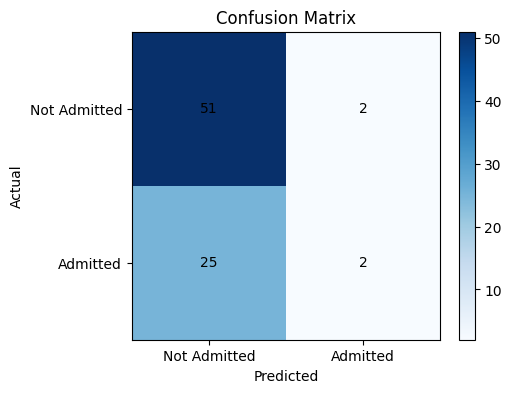

In [10]:
plt.figure(figsize=(5,4))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1], ["Not Admitted", "Admitted"])
plt.yticks([0,1], ["Not Admitted", "Admitted"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],ha="center",va="center",color="black")
plt.show()

In [11]:
sample = [[700, 3.8, 2]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Student is likely to be Admitted.")
else:
    print("Student is unlikely to be Admitted.")

Student is unlikely to be Admitted.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
